In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import skops.io as sio
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'src' / 'load_data.py').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Start Jupyter from the 6Emotions project or a model folder.')
sys.path.insert(0, str(PROJECT_ROOT))
from src.load_data import load_model_data, TARGET_LABELS
from src.features import make_tfidf_features
from src.evaluate import save_confusion_matrices

RANDOM_STATE = 42
JOY_CAP = 12000
C = 1.0
RESULTS_DIR = PROJECT_ROOT / 'models' / 'logreg' / 'results'
ARTIFACT_DIR = PROJECT_ROOT / 'models' / 'logreg' / 'artifacts'

In [2]:
data = load_model_data(base_path=PROJECT_ROOT / 'data', random_state=RANDOM_STATE, joy_cap=JOY_CAP)
full_train_df = data['full_train']
full_test_df = data['full_test']

print(f"Training Size: {len(full_train_df)}")
print(f"Test Size:     {len(full_test_df)}")

Training Size: 39718
Test Size:     5421


In [3]:
model = Pipeline([
    ('features', make_tfidf_features()),
    ('logreg', LogisticRegression(
        C=C,
        max_iter=3000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

In [4]:
model.fit(full_train_df['text'], full_train_df['label'])

# On test set
y_pred = model.predict(full_test_df['text'])
y_true = full_test_df['label']
test_accuracy = float(accuracy_score(y_true, y_pred))

print(f"Test Accuracy: {test_accuracy:.4f}")
print(classification_report(y_true, y_pred, labels=TARGET_LABELS, target_names=TARGET_LABELS))

Test Accuracy: 0.7449
              precision    recall  f1-score   support

     sadness       0.77      0.76      0.77       882
         joy       0.88      0.74      0.80      2297
        love       0.59      0.76      0.66       417
       anger       0.65      0.73      0.69       909
        fear       0.72      0.82      0.77       311
    surprise       0.61      0.71      0.65       605

    accuracy                           0.74      5421
   macro avg       0.70      0.75      0.72      5421
weighted avg       0.76      0.74      0.75      5421



Confusion matrices

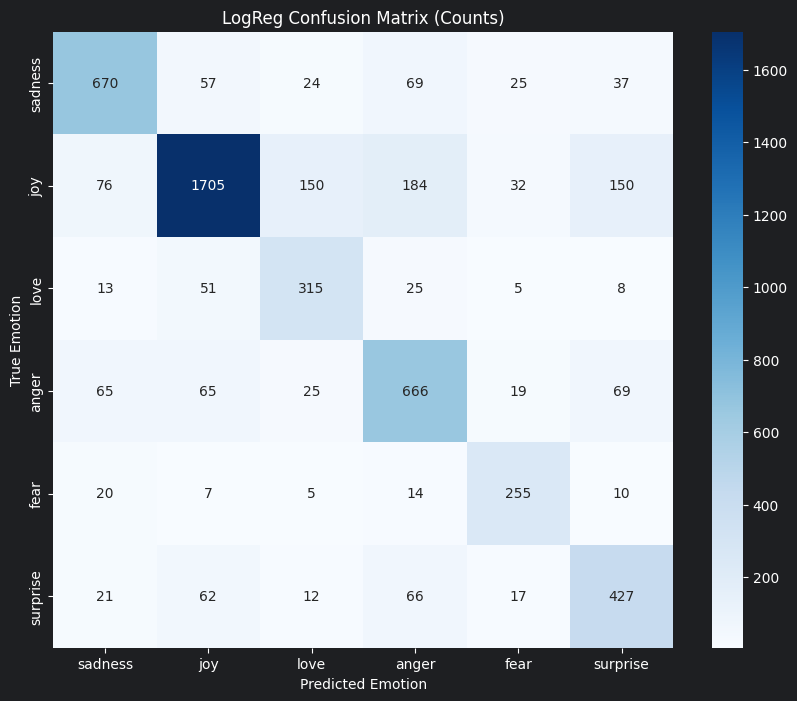

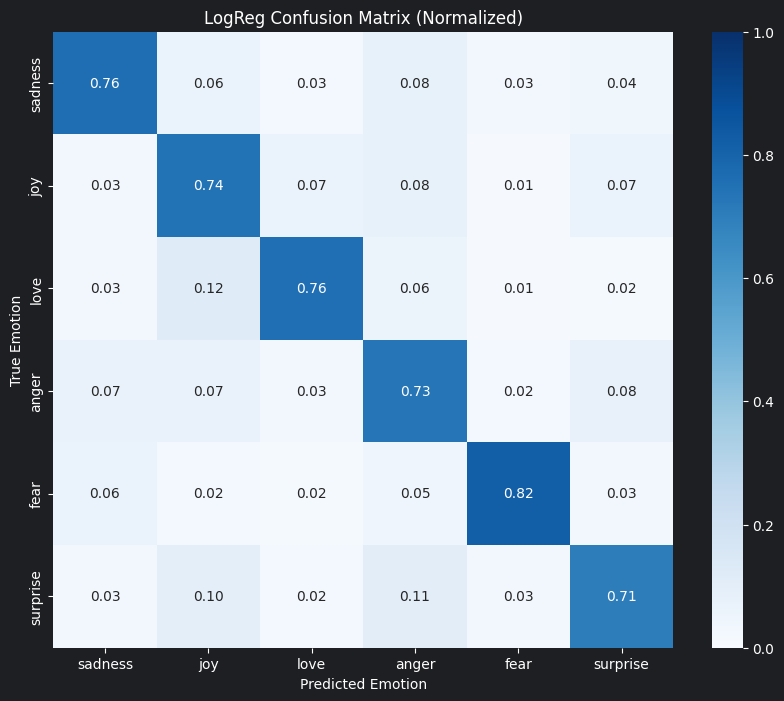

In [5]:
cm = save_confusion_matrices(y_true, y_pred, TARGET_LABELS, RESULTS_DIR, 'LogReg')

In [6]:
classifier = model.named_steps['logreg']
feature_union = model.named_steps['features']

# Get feature names (Words + Chars)
word_names = feature_union.transformer_list[0][1].get_feature_names_out()
char_names = feature_union.transformer_list[1][1].get_feature_names_out()
all_feature_names = np.r_[word_names, char_names]

# Map Coefficients to Words
coef_df = pd.DataFrame(
    classifier.coef_,
    index=classifier.classes_,
    columns=all_feature_names
)

# Top 10 "Trigger Words" for each Emotion
print("Top Explainable Features per Emotion")
for emotion in TARGET_LABELS:
    # Sort by weight (highest positive weight = strongest trigger)
    top_triggers = coef_df.loc[emotion].sort_values(ascending=False).head(10)
    print(f"\nEmotion: {emotion.upper()}")
    for feature, weight in top_triggers.items():
        print(f"  {feature:20} (Weight: {weight:.2f})")

Top Explainable Features per Emotion

Emotion: SADNESS
  sorry                (Weight: 5.49)
  sad                  (Weight: 5.40)
  sad                  (Weight: 4.17)
  sadly                (Weight: 4.15)
  vain                 (Weight: 3.36)
   sad                 (Weight: 3.17)
  dull                 (Weight: 3.10)
  bad                  (Weight: 3.06)
  :(                   (Weight: 3.05)
  needy                (Weight: 2.96)

Emotion: JOY
  lol                  (Weight: 7.38)
  thanks               (Weight: 4.18)
  lol                  (Weight: 3.49)
  great                (Weight: 3.39)
  haha                 (Weight: 3.39)
  happy                (Weight: 2.83)
  hank                 (Weight: 2.75)
  thank                (Weight: 2.75)
  nice                 (Weight: 2.64)
  good                 (Weight: 2.63)

Emotion: LOVE
  horny                (Weight: 5.61)
  love                 (Weight: 5.57)
  naughty              (Weight: 5.39)
  lov                  (Weight: 5.04)
  no

Save the model

In [7]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
model_path = ARTIFACT_DIR / '6emotions_model.skops'
sio.dump(model, model_path)
print(f"Model saved to {model_path}")

summary = {
    'random_state': RANDOM_STATE,
    'training_rows': len(full_train_df),
    'test_rows': len(full_test_df),
    'joy_cap': JOY_CAP,
    'C': C,
    'test_accuracy': test_accuracy,
    'labels': TARGET_LABELS,
}
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'training_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print(f"Training summary saved to {RESULTS_DIR}")

Model saved to /Users/hayden/HaydensOffice/Projects/6Emotions/models/logreg/artifacts/6emotions_model.skops
Training summary saved to /Users/hayden/HaydensOffice/Projects/6Emotions/models/logreg/results
